In [1]:
%load_ext autoreload
%autoreload 2

import os
import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.visualization_utils as visualization_utils
from constants.behavioral_constants import *
from constants.decoding_constants import *
from scripts.pseudo_decoding.belief_partitions.belief_partition_configs import *
import scripts.pseudo_decoding.belief_partitions.belief_partitions_io as belief_partitions_io

plt.rcParams.update({"font.size": 16})

# Preference decoding vs. preference projected onto the choice axis

Preference decoding asks how separable **High X** vs. **High Not X** activity is, in trials where
feature X was chosen and correct. Here we compare it against the separability of those same two
conditions once projected onto the **choice axis** (Chose X vs. Not Chose X, fit on all units),
where the axis direction is fixed and only a threshold along it is refit.

| series | mode | path |
| --- | --- | --- |
| preference | `pref` | `/data/patrick_res/belief_partitions` |
| on choice axis | `pref_on_choice` | `/data/patrick_res/choice_axis_projection_accs` |

The projection is computed by
`scripts/pseudo_decoding/belief_partitions/decode_pref_on_choice_axis.py`, reusing the preference
run's units (`pref_99th_window_filter_drift`), trials (`Response Correct`, `Choice Chose`),
train/test splits and pseudo population generation, so the two are directly comparable. Each is
shown alongside its own session-permute shuffle.

Below the traces, each series gets its own row of significance bars in its own color: preference
on top (blue), the projection beneath it (purple). Both are the one-sided permutation test of that
series against its own shuffle at each timepoint, thicker bars for smaller p (p < 0.05 / 0.01 /
0.001, `visualization_utils.SIG_LEVELS`). Note this asks whether each series beats its own
shuffle, not whether they differ from each other.

Whole population plus the 6 regions of interest, for both StimOnset and FeedbackOnsetLong.

In [2]:
MODE_TO_BASE_PATH = {
    "pref": "/data/patrick_res/belief_partitions",
    "pref_on_choice": "/data/patrick_res/choice_axis_projection_accs",
}

SERIES_NAMES = {
    "pref": "preference",
    "pref_shuffle": "preference shuffle",
    "pref_on_choice": "on choice axis",
    "pref_on_choice_shuffle": "on choice axis shuffle",
}
SERIES_ORDER = ["preference", "preference shuffle", "on choice axis", "on choice axis shuffle"]
SERIES_TO_COLOR = {
    "preference": "tab:blue",
    "preference shuffle": "#aec7e8",
    "on choice axis": "tab:purple",
    "on choice axis shuffle": "#c5b0d5",
}
# series that get a row of significance bars, drawn top to bottom in this order
SIG_BAR_SERIES = ["preference", "on choice axis"]

# whole population, then the 6 regions of interest
POPULATIONS = [(None, None, "whole population")] + [
    ("structure_level2_cleaned", region, region) for region in REGIONS_OF_INTEREST
]


def get_args(mode, region_level, regions, trial_event):
    """
    Configs for one mode's run: only the mode and the path it's stored under differ
    """
    args = argparse.Namespace(**BeliefPartitionConfigs()._asdict())
    args.subject = "both"
    args.mode = mode
    args.beh_filters = {"Response": "Correct", "Choice": "Chose"}
    args.sig_unit_level = "pref_99th_window_filter_drift"
    args.region_level = region_level
    args.regions = regions
    args.trial_event = trial_event
    args.base_output_path = MODE_TO_BASE_PATH[mode]
    return args


def read_both_modes(region_level, regions, trial_event):
    """
    Reads preference and choice-axis-projected accuracies, with their shuffles, into one frame
    """
    res = []
    for mode in MODE_TO_BASE_PATH:
        args = get_args(mode, region_level, regions, trial_event)
        res.append(belief_partitions_io.read_results(args, FEATURES))
    res = pd.concat(res)
    res["series"] = res["mode"].map(SERIES_NAMES)
    res["trial_event"] = trial_event
    return res


def read_pvals(region_level, regions, trial_event):
    """
    Reads each mode's per-timepoint p value against its own shuffle, keyed by series name.
    Both are the same one-sided permutation test (stats_utils.compute_p_for_decoding_by_time),
    written by p_val_computations/compute_p_vals_for_decoders.py for preference and
    p_val_computations/compute_p_vals_for_pref_on_choice.py for the projection.
    """
    p_vals = {}
    for mode in MODE_TO_BASE_PATH:
        args = get_args(mode, region_level, regions, trial_event)
        dir = belief_partitions_io.get_dir_name(args, make_dir=False)
        p_vals[SERIES_NAMES[mode]] = pd.read_pickle(os.path.join(dir, f"{mode}_pvals.pickle"))
    return p_vals

In [3]:
def plot_pref_vs_choice_axis(region_level, regions, title=None):
    """
    Both trial events side by side, in the style of visualization_utils.plot_combined_accs
    """
    stim_res = read_both_modes(region_level, regions, "StimOnset")
    fb_res = read_both_modes(region_level, regions, "FeedbackOnsetLong")

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(12, 3.5), sharey="row",
        width_ratios=[stim_res.Time.nunique(), fb_res.Time.nunique()]
    )
    for ax, res in ((ax1, stim_res), (ax2, fb_res)):
        sns.lineplot(
            res, x="Time", y="Accuracy", hue="series", hue_order=SERIES_ORDER,
            palette=SERIES_TO_COLOR, linewidth=3, ax=ax, errorbar="se"
        )
        ax.axhline(y=0.5, linestyle="dotted", color="black")
        ax.axvline(0, color="grey", linestyle="dotted", linewidth=3)

    # significance vs. each series' own shuffle, a row of bars per series below the traces,
    # colored to match the trace. Spacing is a fraction of the y range, so the rows stay
    # clear of each other whatever the accuracies are: at this figure height it leaves a
    # visible gap between even the thickest (p < 0.001) bars. Read the shared limits first,
    # before any bar has a chance to rescale the axes.
    bottom, top = ax1.get_ylim()
    spacing = 0.08 * (top - bottom)
    for ax, trial_event in ((ax1, "StimOnset"), (ax2, "FeedbackOnsetLong")):
        p_vals = read_pvals(region_level, regions, trial_event)
        for i, series in enumerate(SIG_BAR_SERIES):
            visualization_utils.plot_sig_bars(
                p_vals[series], bottom - (i + 1) * spacing, ax, color=SERIES_TO_COLOR[series]
            )
    # shared y, so these set both: make room for the bars without rescaling the traces, and
    # keep the ticks on the traces, since an accuracy tick in the bar strip reads as data
    ax1.set_ylim(bottom - (len(SIG_BAR_SERIES) + 0.5) * spacing, top)
    ax1.set_yticks([tick for tick in ax1.get_yticks() if bottom <= tick <= top])

    ax1.axvline(-.5, color="grey", linestyle="dotted", linewidth=3)
    ax1.set_xlabel("Time to stimuli appear (s)")
    stim_ticks = [-1, -.5, 0, .5, 1]
    ax1.set_xticks(stim_ticks)
    ax1.set_xticklabels(stim_ticks)
    ax1.set_ylabel("Accuracy")

    ax2.axvline(-.8, color="grey", linestyle="dotted", linewidth=3)
    ax2.set_xlabel("Time to feedback (s)")
    fb_ticks = [-1.5, -1, -.5, 0, .5, 1, 1.5]
    ax2.set_xticks(fb_ticks)
    ax2.set_xticklabels(fb_ticks)

    visualization_utils.format_plot([ax1, ax2])
    ax1.get_legend().remove()
    legend = ax2.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    for line in legend.get_lines():
        line.set_linewidth(6)
    if title:
        ax1.set_title(title, loc="left")
    fig.tight_layout()
    return fig, (ax1, ax2), pd.concat((stim_res, fb_res))

## Whole population

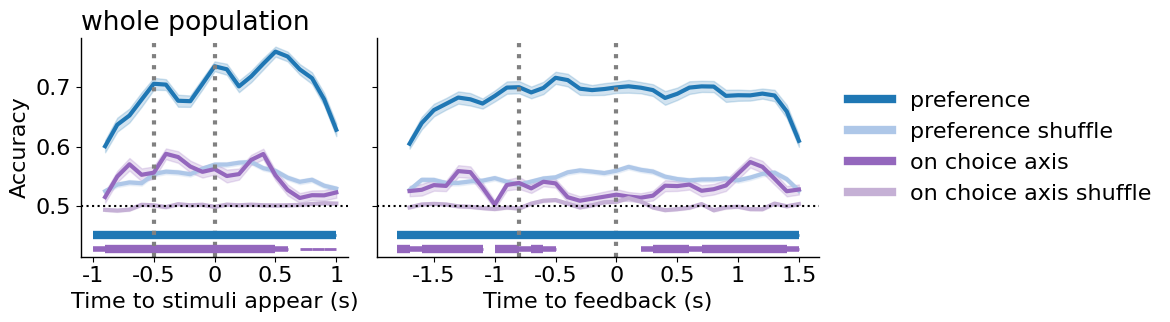

In [4]:
fig, _, whole_pop_res = plot_pref_vs_choice_axis(None, None, title="whole population")

## Regions of interest

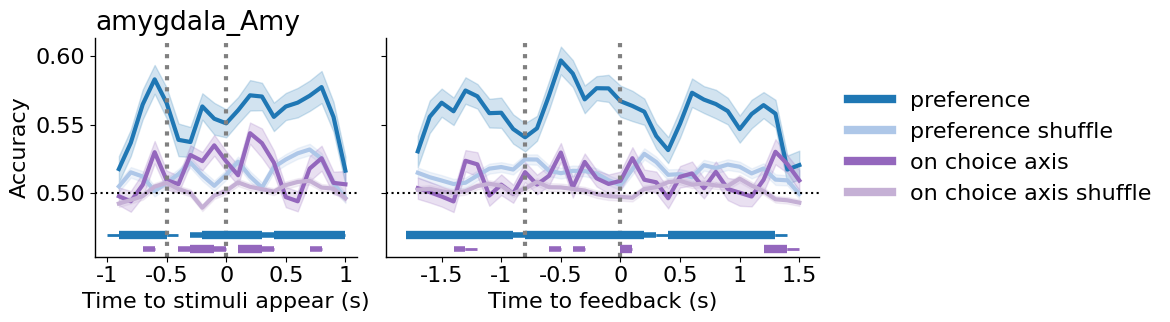

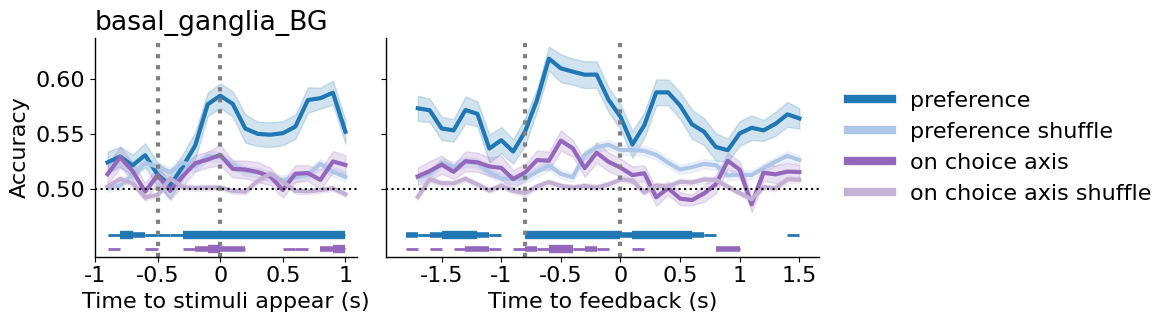

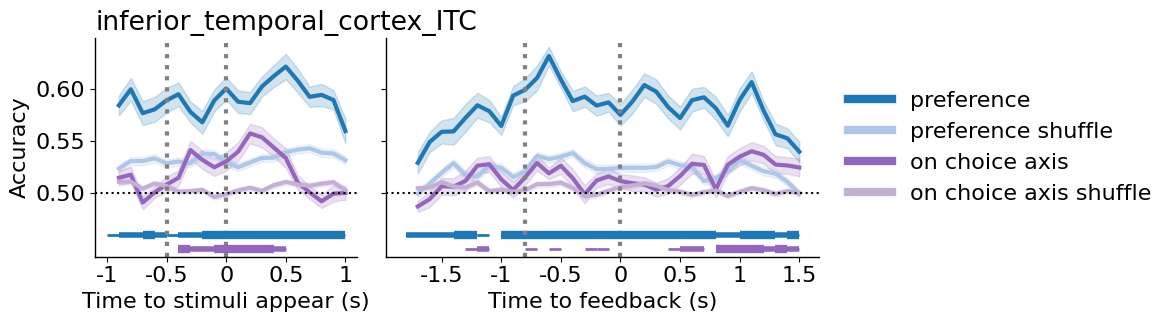

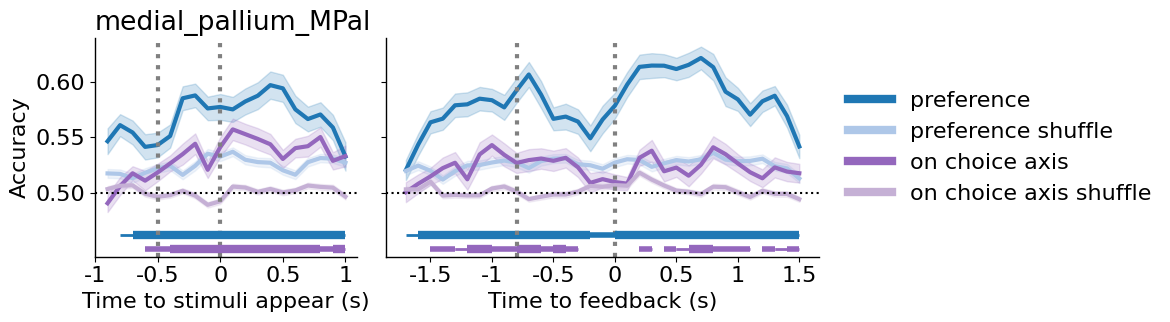

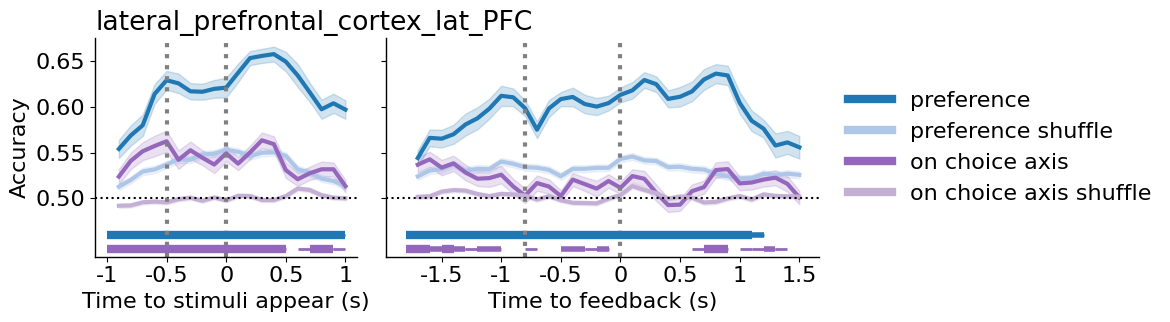

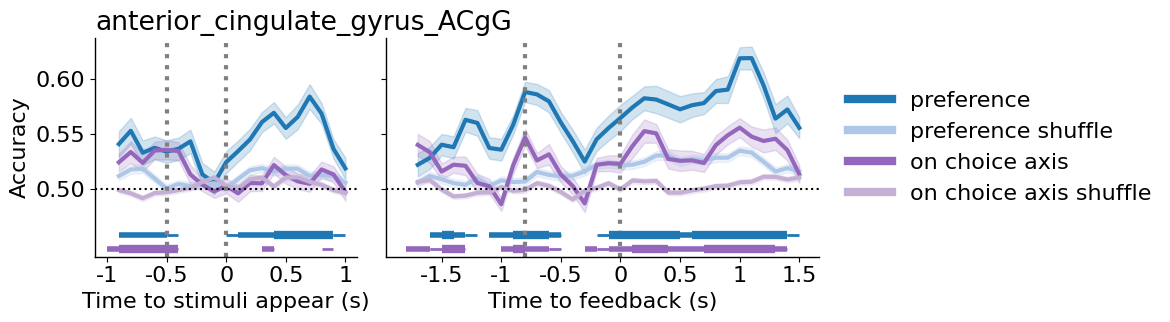

In [5]:
all_res = [whole_pop_res.assign(population="whole population")]
for region_level, regions, name in POPULATIONS[1:]:
    _, _, res = plot_pref_vs_choice_axis(region_level, regions, title=name)
    all_res.append(res.assign(population=name))
all_res = pd.concat(all_res)

## Summary

Mean accuracy over all time bins, features and runs, alongside each series' distance above its own
shuffle. `frac` is how much of preference's separation over its own shuffle is recovered on the
choice axis.

In [6]:
summary = all_res.groupby(["population", "trial_event", "series"]).Accuracy.mean().unstack("series")
summary["pref gap"] = summary["preference"] - summary["preference shuffle"]
summary["proj gap"] = summary["on choice axis"] - summary["on choice axis shuffle"]
summary["frac"] = summary["proj gap"] / summary["pref gap"]
summary = summary.reindex(
    [name for _, _, name in POPULATIONS], level="population"
).reindex(["StimOnset", "FeedbackOnsetLong"], level="trial_event")
summary.round(3)

series                                               on choice axis  \
population                        trial_event                         
whole population                  StimOnset                   0.551   
                                  FeedbackOnsetLong           0.532   
amygdala_Amy                      StimOnset                   0.516   
                                  FeedbackOnsetLong           0.510   
basal_ganglia_BG                  StimOnset                   0.515   
                                  FeedbackOnsetLong           0.515   
inferior_temporal_cortex_ITC      StimOnset                   0.521   
                                  FeedbackOnsetLong           0.517   
medial_pallium_MPal               StimOnset                   0.532   
                                  FeedbackOnsetLong           0.523   
lateral_prefrontal_cortex_lat_PFC StimOnset                   0.541   
                                  FeedbackOnsetLong           0.518   
anterior_cingulate_gyrus_ACgG     StimOnset                   0.514   
                                  FeedbackOnsetLong           0.527   

series                                               on choice axis shuffle  \
population                        trial_event                                 
whole population                  StimOnset                           0.501   
                                  FeedbackOnsetLong                   0.501   
amygdala_Amy                      StimOnset                           0.502   
                                  FeedbackOnsetLong                   0.503   
basal_ganglia_BG                  StimOnset                           0.502   
                                  FeedbackOnsetLong                   0.503   
inferior_temporal_cortex_ITC      StimOnset                           0.506   
                                  FeedbackOnsetLong                   0.504   
medial_pallium_MPal               StimOnset                           0.501   
                                  FeedbackOnsetLong                   0.502   
lateral_prefrontal_cortex_lat_PFC StimOnset                           0.500   
                                  FeedbackOnsetLong                   0.502   
anterior_cingulate_gyrus_ACgG     StimOnset                           0.502   
                                  FeedbackOnsetLong                   0.502   

series                                               preference  \
population                        trial_event                     
whole population                  StimOnset               0.697   
                                  FeedbackOnsetLong       0.685   
amygdala_Amy                      StimOnset               0.556   
                                  FeedbackOnsetLong       0.559   
basal_ganglia_BG                  StimOnset               0.549   
                                  FeedbackOnsetLong       0.567   
inferior_temporal_cortex_ITC      StimOnset               0.591   
                                  FeedbackOnsetLong       0.581   
medial_pallium_MPal               StimOnset               0.568   
                                  FeedbackOnsetLong       0.582   
lateral_prefrontal_cortex_lat_PFC StimOnset               0.618   
                                  FeedbackOnsetLong       0.597   
anterior_cingulate_gyrus_ACgG     StimOnset               0.543   
                                  FeedbackOnsetLong       0.566   

series                                               preference shuffle  \
population                        trial_event                             
whole population                  StimOnset                       0.552   
                                  FeedbackOnsetLong               0.548   
amygdala_Amy                      StimOnset                       0.514   
                                  FeedbackOnsetLong               0.515   
basal_ganglia_BG                  StimOnset                       0.516   
